# ResNet-50 + Wavelet Features v5: Two-Stage Cascade (deeper Stage 2 + augmentation)

## v1 -> v2 -> v3 -> v4 -> v5, based on actually running each version

- **v1**: flat `MALIGNANT_BOOST = 1.3`. Test F1 74.42%. Benign-vs-Malignant accuracy ~71.7% (derived).
- **v2**: measured, asymmetric weight -- let the stronger class drop below 1.0. Test F1 74.48%,
  Benign-vs-Malignant accuracy 70.06% (a real tradeoff, not a win).
- **v3**: fixed the weight-floor bug, but the measured gap was small that run. Benign-vs-Malignant
  accuracy 69.45% -- three rounds of weight tuning landed in a flat 69-72% band with no reliable winner.
- **v4**: pivoted to a two-stage cascade instead of more weight tuning. **Best result in the project so
  far: cascade test accuracy/F1 75%.** Breaking it down: Stage 1 (Normal vs. Abnormal) is excellent
  (92.86% accuracy, 0.96 recall on Abnormal). Stage 2 standalone (Benign vs. Malignant, clean subset) hit
  74.00% -- already better than v1-v3's numbers. But the end-to-end cascade's Benign-vs-Malignant
  accuracy (71.49%) is lower than Stage 2's own standalone number, because ~4% of true Benign/Malignant
  cases get routed to Normal by Stage 1 before Stage 2 ever sees them, on top of Stage 2's own ~26% error
  rate on what it does see.
- **v5** (this version): with Stage 1 already at 96% Abnormal recall, there's little room left there --
  essentially all the remaining opportunity is in Stage 2's own ~26% error rate. Two changes target that
  directly:
  1. **Flip augmentation, added to Stage 2's training generator only.** Neither this notebook nor v1-v3
     ever used any augmentation, and Stage 2 now trains on a smaller subset (Benign+Malignant only,
     ~2/3 of the original data) than v1-v3 did. Stage 1 is untouched -- it's already excellent, no
     reason to disturb it.
  2. **`FINETUNE_UNFREEZE_LAST_N_STAGE2`: 50 -> 175 (fully unfrozen).** Stage 2 has no competing easy
     class to protect by staying partly frozen, unlike Stage 1 -- there's room to let it use more of
     the backbone's capacity for the finer Benign/Malignant distinction.
  3. **NEW: error attribution at the end** -- splits the remaining Benign/Malignant error into "lost to
     Stage 1 routing" vs. "lost to Stage 2's own discrimination," so it's visible directly which stage
     to blame if the result still disappoints, rather than needing to re-derive it by hand as done above.

### Expected data layout (unchanged)
```
Supervised_Balanced/
    train/<class>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# DATASET PATH
# ==========================================================
print("start")

import os

balanced_dataset = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

print("Balanced dataset ready")


start
Balanced dataset ready


In [2]:
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [3]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops

from sklearn.metrics import classification_report, confusion_matrix, f1_score

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence, to_categorical
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [4]:
# ==========================================================
# CONFIGURATION
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Preprocessed_Pipeline\Supervised_Balanced"

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
BATCH_SIZE = 32

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2
GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 3]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

# --- Stage 1: Normal vs Abnormal ---
STAGE1_EPOCHS_PHASE1 = 150
STAGE1_EPOCHS_FINETUNE = 40
FINETUNE_UNFREEZE_LAST_N_STAGE1 = 30   # unchanged from v1-v3

# --- Stage 2: Benign vs Malignant (dedicated specialist) ---
STAGE2_EPOCHS_PHASE1 = 150
STAGE2_EPOCHS_FINETUNE = 40
FINETUNE_UNFREEZE_LAST_N_STAGE2 = 175  # v5: fully unfrozen (ResNet50 has ~175 layers) -- v4's
                                         # standalone Stage 2 accuracy (74.00%) still had ~26% error
                                         # left, and unlike Stage 1, Stage 2 has no easy class at risk
                                         # of being destabilized by unfreezing further.

train_dir = os.path.join(DATASET_PATH, "train")
val_dir = os.path.join(DATASET_PATH, "val")
test_dir = os.path.join(DATASET_PATH, "test")

print("done1")


start
done1


In [5]:
# ==========================================================
# HANDCRAFTED FEATURE EXTRACTION: WAVELET (DWT) + GLCM  (unchanged from v2/v3)
# ==========================================================
print("start")

def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)

    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)
    dwt_features = []
    for idx, c in enumerate(coeffs):
        sub_bands = [c] if idx == 0 else list(c)
        for sub in sub_bands:
            dwt_features.append(sub.mean())
            dwt_features.append(sub.std())
            dwt_features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)

    img_scaled = (gray.astype(np.float32) / 255.0 * (GLCM_LEVELS - 1)).astype(np.uint8)
    glcm = graycomatrix(img_scaled, distances=GLCM_DISTANCES, angles=GLCM_ANGLES,
                         levels=GLCM_LEVELS, symmetric=True, normed=True)
    glcm_features = []
    for prop in GLCM_PROPERTIES:
        vals = graycoprops(glcm, prop)
        glcm_features.append(float(vals.mean()))
        glcm_features.append(float(vals.std()))

    return np.concatenate([
        np.array(dwt_features, dtype=np.float32),
        np.array(glcm_features, dtype=np.float32)
    ])


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Combined DWT+GLCM feature vector length: {WAVELET_FEATURE_DIM}")
print("done1")


start
Combined DWT+GLCM feature vector length: 33
done1


In [6]:
# ==========================================================
# GENERIC DUAL-INPUT DATA GENERATOR  (v4: extended with allowed_classes + label_remap, like the
# cascade generator used in the semi-supervised pipeline's v6)
# ==========================================================
def augment_image(img_rgb):
    # v5 NEW -- flip only, applied to Stage 2 only (see the generator's `augment` flag). Stage 1 is
    # already excellent (92.86% acc, 0.96 Abnormal recall) and is left untouched; Stage 2 trains on a
    # smaller subset (Benign+Malignant only, ~2/3 of the data) and, unlike v1-v3, had no augmentation
    # at all until now.
    if np.random.rand() < 0.5:
        img_rgb = np.ascontiguousarray(np.fliplr(img_rgb))
    return img_rgb


class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=2, shuffle=True, allowed_classes=None, label_remap=None, augment=False):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.label_remap = label_remap
        self.augment = augment

        all_classes = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_names = [c for c in all_classes if allowed_classes is None or c in allowed_classes]

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    if self.label_remap is not None:
                        self.labels.append(self.label_remap[cls])
                    else:
                        self.labels.append(self.class_names.index(cls))

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.filepaths) / self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)
            if self.augment:
                img_rgb = augment_image(img_rgb)

            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32).copy())
            batch_labels[i] = to_categorical(self.labels[fi], num_classes=self.num_classes)

        return (batch_images, batch_wavelets), batch_labels

    @property
    def classes(self):
        return self.labels

print("ResNetWaveletGenerator (v4) ready")


ResNetWaveletGenerator (v4) ready


In [7]:
# ==========================================================
# GENERIC MODEL BUILDER (used for both stages -- only NUM_CLASSES/architecture differ if needed)
# ==========================================================
print("start")

def get_ResNet50_Wavelet_Hybrid(num_classes, learning_rate=1e-4):
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(input_tensor=image_input, weights='imagenet', include_top=False)
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(0.3)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu')(x_wav)
    x_wav = Dropout(0.3)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu')(fused)
    fused = Dropout(0.3)(fused)
    output = Dense(num_classes, activation='softmax')(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=learning_rate),
        metrics=["accuracy",
                 tfa.metrics.F1Score(num_classes=num_classes, average='macro', name='f1_score'),
                 tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
    )
    return model, base_model


class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


## STAGE 1: Normal vs. Abnormal


In [8]:
# ==========================================================
# STAGE 1 GENERATORS (Normal=0, Abnormal=1; Benign+Malignant merged)
# ==========================================================
print("start")

stage1_label_remap = {"Normal": 0, "Benign": 1, "Malignant": 1}

stage1_train_generator = ResNetWaveletGenerator(train_dir, num_classes=2, shuffle=True, label_remap=stage1_label_remap)
stage1_val_generator = ResNetWaveletGenerator(val_dir, num_classes=2, shuffle=False, label_remap=stage1_label_remap)
stage1_test_generator = ResNetWaveletGenerator(test_dir, num_classes=2, shuffle=False, label_remap=stage1_label_remap)

print("Stage 1 train/val/test sizes:", len(stage1_train_generator.filepaths),
      len(stage1_val_generator.filepaths), len(stage1_test_generator.filepaths))
print("Stage 1 label meaning: 0 = Normal, 1 = Abnormal (Benign or Malignant)")

print("done1")


start
Stage 1 train/val/test sizes: 18000 2965 2943
Stage 1 label meaning: 0 = Normal, 1 = Abnormal (Benign or Malignant)
done1


In [9]:
# ==========================================================
# STAGE 1 TRAINING: PHASE 1 (frozen backbone)
# ==========================================================
print("start")

stage1_model, stage1_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)

stage1_early_stop = EarlyStopping(monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1)
stage1_reduce_lr = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=5e-8, verbose=1)
stage1_checkpoint = ModelCheckpoint("Stage1_NormalVsAbnormal_Initial_v5.h5", monitor='val_f1_score',
                                      save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage1_history_initial = stage1_model.fit(
    stage1_train_generator, validation_data=stage1_val_generator, epochs=STAGE1_EPOCHS_PHASE1,
    callbacks=[stage1_early_stop, stage1_reduce_lr, stage1_checkpoint, lr_callback]
)

print("done1")


start
Epoch 1/150
563/563 [==============================] - ETA: 0s - loss: 0.4445 - accuracy: 0.7847 - f1_score: 0.7525 - precision: 0.7847 - recall: 0.7847
Epoch 1: val_f1_score improved from -inf to 0.82880, saving model to Stage1_NormalVsAbnormal_Initial_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 340s 600ms/step - loss: 0.4445 - accuracy: 0.7847 - f1_score: 0.7525 - precision: 0.7847 - recall: 0.7847 - val_loss: 0.3016 - val_accuracy: 0.8661 - val_f1_score: 0.8288 - val_precision: 0.8661 - val_recall: 0.8661 - lr: 1.0000e-04
Epoch 2/150
563/563 [==============================] - ETA: 0s - loss: 0.3354 - accuracy: 0.8402 - f1_score: 0.8179 - precision: 0.8402 - recall: 0.8402
Epoch 2: val_f1_score improved from 0.82880 to 0.84370, saving model to Stage1_NormalVsAbnormal_Initial_v5.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
563/563 [==============================] - 299s 530ms/step - loss: 0.3354 - accuracy: 0.8402 - f1_sco

In [10]:
# ==========================================================
# STAGE 1 TRAINING: PHASE 2 (fine-tune last 30 layers -- unchanged from v1-v3's structure)
# ==========================================================
print("start")

stage1_model, stage1_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)
stage1_model.load_weights("Stage1_NormalVsAbnormal_Initial_v5.h5")

stage1_base_model.trainable = True
for layer in stage1_base_model.layers[:-FINETUNE_UNFREEZE_LAST_N_STAGE1]:
    layer.trainable = False
for layer in stage1_base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

stage1_model.compile(
    loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy", tfa.metrics.F1Score(num_classes=2, average='macro', name='f1_score'),
             tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

stage1_early_stop_ft = EarlyStopping(monitor='val_f1_score', mode='max', patience=10, restore_best_weights=True, verbose=1)
stage1_reduce_lr_ft = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1)
stage1_checkpoint_ft = ModelCheckpoint("Stage1_NormalVsAbnormal_FineTuned_v5.h5", monitor='val_f1_score',
                                         save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage1_history_finetune = stage1_model.fit(
    stage1_train_generator, validation_data=stage1_val_generator, epochs=STAGE1_EPOCHS_FINETUNE,
    callbacks=[stage1_early_stop_ft, stage1_reduce_lr_ft, stage1_checkpoint_ft, lr_callback]
)

stage1_model.load_weights("Stage1_NormalVsAbnormal_FineTuned_v5.h5")
print("Stage 1 fine-tuned weights loaded")
print("done1")


start
Epoch 1/40
563/563 [==============================] - ETA: 0s - loss: 0.1748 - accuracy: 0.9226 - f1_score: 0.9126 - precision: 0.9226 - recall: 0.9226
Epoch 1: val_f1_score improved from -inf to 0.89118, saving model to Stage1_NormalVsAbnormal_FineTuned_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 284s 502ms/step - loss: 0.1748 - accuracy: 0.9226 - f1_score: 0.9126 - precision: 0.9226 - recall: 0.9226 - val_loss: 0.1837 - val_accuracy: 0.9157 - val_f1_score: 0.8912 - val_precision: 0.9157 - val_recall: 0.9157 - lr: 1.0000e-05
Epoch 2/40
563/563 [==============================] - ETA: 0s - loss: 0.1400 - accuracy: 0.9391 - f1_score: 0.9313 - precision: 0.9391 - recall: 0.9391
Epoch 2: val_f1_score did not improve from 0.89118

Epoch 2 Learning Rate : 9.999999747378752e-06
563/563 [==============================] - 294s 522ms/step - loss: 0.1400 - accuracy: 0.9391 - f1_score: 0.9313 - precision: 0.9391 - recall: 0.9391 - val_loss:

In [11]:
# ==========================================================
# STAGE 1 EVALUATION (sanity check before building the cascade)
# ==========================================================
print("start")

stage1_test_results = stage1_model.evaluate(stage1_test_generator, verbose=1)
print("Stage 1 test: loss=%.4f acc=%.4f f1=%.4f precision=%.4f recall=%.4f" % tuple(stage1_test_results))

stage1_test_preds = stage1_model.predict(stage1_test_generator, verbose=1)
stage1_test_pred_classes = np.argmax(stage1_test_preds, axis=1)
print("\nStage 1 classification report (0=Normal, 1=Abnormal):")
print(classification_report(stage1_test_generator.classes, stage1_test_pred_classes,
                             target_names=["Normal", "Abnormal"]))

print("done1")


start
92/92 [==============================] - 48s 519ms/step - loss: 0.2955 - accuracy: 0.9212 - f1_score: 0.8987 - precision: 0.9212 - recall: 0.9212
Stage 1 test: loss=0.2955 acc=0.9212 f1=0.8987 precision=0.9212 recall=0.9212
92/92 [==============================] - 42s 449ms/step

Stage 1 classification report (0=Normal, 1=Abnormal):
              precision    recall  f1-score   support

      Normal       0.86      0.84      0.85       789
    Abnormal       0.94      0.95      0.95      2154

    accuracy                           0.92      2943
   macro avg       0.90      0.90      0.90      2943
weighted avg       0.92      0.92      0.92      2943

done1


## STAGE 2: Benign vs. Malignant (dedicated specialist, no class weighting)


In [12]:
# ==========================================================
# STAGE 2 GENERATORS (Benign=0, Malignant=1 -- only these two classes are read at all)
# ==========================================================
print("start")

stage2_label_remap = {"Benign": 0, "Malignant": 1}

stage2_train_generator = ResNetWaveletGenerator(
    train_dir, num_classes=2, shuffle=True, allowed_classes=["Benign", "Malignant"],
    label_remap=stage2_label_remap, augment=True   # v5 NEW -- flip augmentation, train only
)
stage2_val_generator = ResNetWaveletGenerator(
    val_dir, num_classes=2, shuffle=False, allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap
)
stage2_test_generator = ResNetWaveletGenerator(
    test_dir, num_classes=2, shuffle=False, allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap
)

print("Stage 2 train/val/test sizes (Benign+Malignant only):",
      len(stage2_train_generator.filepaths), len(stage2_val_generator.filepaths), len(stage2_test_generator.filepaths))
print("Stage 2 label meaning: 0 = Benign, 1 = Malignant")
print("No class weighting -- Benign/Malignant are close to 1:1 in labeled_train already, and three")
print("rounds of weight-tuning (v1-v3) showed reweighting doesn't reliably help this specific pair.")

print("done1")


start
Stage 2 train/val/test sizes (Benign+Malignant only): 12000 2170 2154
Stage 2 label meaning: 0 = Benign, 1 = Malignant
No class weighting -- Benign/Malignant are close to 1:1 in labeled_train already, and three
rounds of weight-tuning (v1-v3) showed reweighting doesn't reliably help this specific pair.
done1


In [13]:
# ==========================================================
# STAGE 2 TRAINING: PHASE 1 (frozen backbone, Benign/Malignant only)
# ==========================================================
print("start")

stage2_model, stage2_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)

stage2_early_stop = EarlyStopping(monitor='val_f1_score', mode='max', patience=11, restore_best_weights=True, verbose=1)
stage2_reduce_lr = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3, patience=5, min_lr=5e-8, verbose=1)
stage2_checkpoint = ModelCheckpoint("Stage2_BenignVsMalignant_Initial_v5.h5", monitor='val_f1_score',
                                      save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage2_history_initial = stage2_model.fit(
    stage2_train_generator, validation_data=stage2_val_generator, epochs=STAGE2_EPOCHS_PHASE1,
    callbacks=[stage2_early_stop, stage2_reduce_lr, stage2_checkpoint, lr_callback]
)

print("done1")


start
Epoch 1/150
375/375 [==============================] - ETA: 0s - loss: 0.7094 - accuracy: 0.6008 - f1_score: 0.6008 - precision: 0.6008 - recall: 0.6008
Epoch 1: val_f1_score improved from -inf to 0.66557, saving model to Stage2_BenignVsMalignant_Initial_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
375/375 [==============================] - 180s 477ms/step - loss: 0.7094 - accuracy: 0.6008 - f1_score: 0.6008 - precision: 0.6008 - recall: 0.6008 - val_loss: 0.6107 - val_accuracy: 0.6724 - val_f1_score: 0.6656 - val_precision: 0.6724 - val_recall: 0.6724 - lr: 1.0000e-04
Epoch 2/150
375/375 [==============================] - ETA: 0s - loss: 0.6242 - accuracy: 0.6520 - f1_score: 0.6520 - precision: 0.6520 - recall: 0.6520
Epoch 2: val_f1_score improved from 0.66557 to 0.68107, saving model to Stage2_BenignVsMalignant_Initial_v5.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
375/375 [==============================] - 191s 508ms/step - loss: 0.6242 - accuracy: 0.6520 - f1_s

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [14]:
# ==========================================================
# STAGE 2 TRAINING: PHASE 2 (fine-tune -- deeper unfreeze than Stage 1, this is the whole point)
# ==========================================================
print("start")

stage2_model, stage2_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)
stage2_model.load_weights("Stage2_BenignVsMalignant_Initial_v5.h5")

stage2_base_model.trainable = True
for layer in stage2_base_model.layers[:-FINETUNE_UNFREEZE_LAST_N_STAGE2]:
    layer.trainable = False
for layer in stage2_base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

stage2_model.compile(
    loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy", tfa.metrics.F1Score(num_classes=2, average='macro', name='f1_score'),
             tf.keras.metrics.Precision(name='precision'), tf.keras.metrics.Recall(name='recall')]
)

stage2_early_stop_ft = EarlyStopping(monitor='val_f1_score', mode='max', patience=10, restore_best_weights=True, verbose=1)
stage2_reduce_lr_ft = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3, patience=4, min_lr=1e-8, verbose=1)
stage2_checkpoint_ft = ModelCheckpoint("Stage2_BenignVsMalignant_FineTuned_v5.h5", monitor='val_f1_score',
                                         save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage2_history_finetune = stage2_model.fit(
    stage2_train_generator, validation_data=stage2_val_generator, epochs=STAGE2_EPOCHS_FINETUNE,
    callbacks=[stage2_early_stop_ft, stage2_reduce_lr_ft, stage2_checkpoint_ft, lr_callback]

    
)

stage2_model.load_weights("Stage2_BenignVsMalignant_FineTuned_v5.h5")
print("Stage 2 fine-tuned weights loaded")
print("done1")


start
Epoch 1/40
375/375 [==============================] - ETA: 0s - loss: 0.4949 - accuracy: 0.7530 - f1_score: 0.7528 - precision: 0.7530 - recall: 0.7530
Epoch 1: val_f1_score improved from -inf to 0.73406, saving model to Stage2_BenignVsMalignant_FineTuned_v5.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
375/375 [==============================] - 190s 500ms/step - loss: 0.4949 - accuracy: 0.7530 - f1_score: 0.7528 - precision: 0.7530 - recall: 0.7530 - val_loss: 0.5241 - val_accuracy: 0.7406 - val_f1_score: 0.7341 - val_precision: 0.7406 - val_recall: 0.7406 - lr: 1.0000e-05
Epoch 2/40
375/375 [==============================] - ETA: 0s - loss: 0.4493 - accuracy: 0.7824 - f1_score: 0.7823 - precision: 0.7824 - recall: 0.7824
Epoch 2: val_f1_score improved from 0.73406 to 0.74393, saving model to Stage2_BenignVsMalignant_FineTuned_v5.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
375/375 [==============================] - 185s 492ms/step - loss: 0.4493 - accuracy: 0.7824 - f1

In [15]:
# ==========================================================
# STAGE 2 STANDALONE EVALUATION (Benign/Malignant test subset only, before cascading)
# ==========================================================
print("start")

stage2_test_results = stage2_model.evaluate(stage2_test_generator, verbose=1)
print("Stage 2 test (Benign/Malignant only): loss=%.4f acc=%.4f f1=%.4f precision=%.4f recall=%.4f"
      % tuple(stage2_test_results))

stage2_test_preds = stage2_model.predict(stage2_test_generator, verbose=1)
stage2_test_pred_classes = np.argmax(stage2_test_preds, axis=1)
print("\nStage 2 classification report (0=Benign, 1=Malignant), Benign/Malignant test images only:")
print(classification_report(stage2_test_generator.classes, stage2_test_pred_classes,
                             target_names=["Benign", "Malignant"]))

print("done1")


start
68/68 [==============================] - 29s 419ms/step - loss: 0.5526 - accuracy: 0.7382 - f1_score: 0.7320 - precision: 0.7382 - recall: 0.7382
Stage 2 test (Benign/Malignant only): loss=0.5526 acc=0.7382 f1=0.7320 precision=0.7382 recall=0.7382
68/68 [==============================] - 29s 411ms/step

Stage 2 classification report (0=Benign, 1=Malignant), Benign/Malignant test images only:
              precision    recall  f1-score   support

      Benign       0.67      0.71      0.69       888
   Malignant       0.79      0.76      0.77      1266

    accuracy                           0.74      2154
   macro avg       0.73      0.73      0.73      2154
weighted avg       0.74      0.74      0.74      2154

done1


## CASCADE: combine Stage 1 + Stage 2, score against the full 3-class test set


start
68/68 [==============================] - 2s 29ms/step

Cascade Classification Report (full 3-class test set):
              precision    recall  f1-score   support

      Benign       0.60      0.66      0.63       888
   Malignant       0.77      0.73      0.75      1266
      Normal       0.86      0.84      0.85       789

    accuracy                           0.74      2943
   macro avg       0.74      0.74      0.74      2943
weighted avg       0.74      0.74      0.74      2943



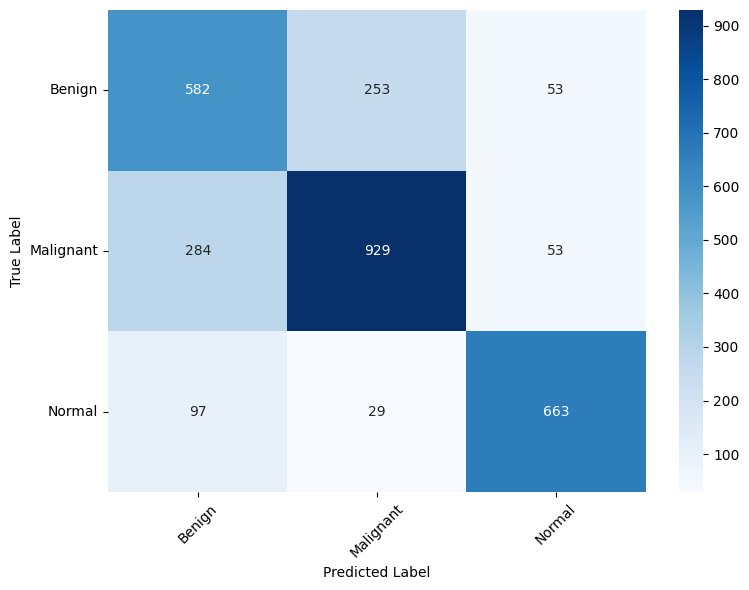


Raw cascade confusion matrix:
Classes: ['Benign', 'Malignant', 'Normal']
[[582 253  53]
 [284 929  53]
 [ 97  29 663]]

Per-class error breakdown:

  True Benign (n=888): 582 correct (65.5%)
    -> misclassified as Malignant: 253 (28.5%)
    -> misclassified as Normal: 53 (6.0%)

  True Malignant (n=1266): 929 correct (73.4%)
    -> misclassified as Benign: 284 (22.4%)
    -> misclassified as Normal: 53 (4.2%)

  True Normal (n=789): 663 correct (84.0%)
    -> misclassified as Benign: 97 (12.3%)
    -> misclassified as Malignant: 29 (3.7%)

Benign-vs-Malignant target metric on the cascade (n=2154): 70.15%
(compare directly against v1: ~71.7%, v2: 70.06%, v3: 69.45%, v4: 71.49%)

Error attribution on the 2154 true Benign/Malignant test cases:
  Lost to Stage 1 routing (sent to Normal, never reached Stage 2): 106 (4.9%)
  Reached Stage 2: 2048 -- of those, Stage 2 got 537 wrong (26.2% of the ones it saw)
done1


In [16]:
# ==========================================================
# FULL 3-CLASS CASCADE EVALUATION ON THE TEST SET
# ==========================================================
print("start")

full_test_generator = ResNetWaveletGenerator(test_dir, num_classes=3, shuffle=False)
class_names_3way = full_test_generator.class_names   # sorted: Benign, Malignant, Normal
true_classes_test = full_test_generator.classes

# Stage 1: Normal vs Abnormal on every test image
stage1_preds_full = stage1_model.predict(stage1_test_generator, verbose=1)
stage1_pred_is_abnormal = np.argmax(stage1_preds_full, axis=1) == 1

# Default every prediction to Normal, then override with Stage 2 wherever Stage 1 said Abnormal
final_predictions = np.array([class_names_3way.index("Normal")] * len(full_test_generator.filepaths))
filepath_to_final_idx = {fp: i for i, fp in enumerate(full_test_generator.filepaths)}

abnormal_idx = np.where(stage1_pred_is_abnormal)[0]
if len(abnormal_idx) > 0:
    abnormal_filepaths = np.array(full_test_generator.filepaths)[abnormal_idx]
    # Run every Stage-1-flagged-Abnormal image through Stage 2 directly (no folder restriction needed
    # here since we already have the exact filepaths -- avoids the Normal-leakage edge case the
    # semi-supervised pipeline's v6 cascade had to work around).
    stage2_cascade_images = np.zeros((len(abnormal_filepaths), *IMAGE_SIZE, 3), dtype=np.float32)
    stage2_cascade_wavelets = np.zeros((len(abnormal_filepaths), WAVELET_FEATURE_DIM), dtype=np.float32)
    for i, fp in enumerate(abnormal_filepaths):
        img_bgr = cv2.imread(fp)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        img_rgb = cv2.resize(img_rgb, IMAGE_SIZE)
        stage2_cascade_wavelets[i] = extract_wavelet_features(img_rgb)
        stage2_cascade_images[i] = preprocess_input(img_rgb.astype(np.float32).copy())

    stage2_cascade_preds = stage2_model.predict([stage2_cascade_images, stage2_cascade_wavelets], verbose=1)
    stage2_cascade_pred_classes = np.argmax(stage2_cascade_preds, axis=1)

    for fp, pred in zip(abnormal_filepaths, stage2_cascade_pred_classes):
        final_class_name = "Benign" if pred == 0 else "Malignant"
        final_predictions[filepath_to_final_idx[fp]] = class_names_3way.index(final_class_name)

print("\nCascade Classification Report (full 3-class test set):")
print(classification_report(true_classes_test, final_predictions, target_names=class_names_3way))

cm_cascade = confusion_matrix(true_classes_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cascade, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_3way, yticklabels=class_names_3way)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Cascade_confusion_matrix_test_v5.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("\nRaw cascade confusion matrix:")
print("Classes:", class_names_3way)
print(cm_cascade)

print("\nPer-class error breakdown:")
for i, true_cls in enumerate(class_names_3way):
    total = cm_cascade[i].sum()
    if total == 0:
        continue
    correct = cm_cascade[i, i]
    print(f"\n  True {true_cls} (n={total}): {correct} correct ({100*correct/total:.1f}%)")
    for j, pred_cls in enumerate(class_names_3way):
        if i == j:
            continue
        n_err = cm_cascade[i, j]
        if n_err > 0:
            print(f"    -> misclassified as {pred_cls}: {n_err} ({100*n_err/total:.1f}%)")

b_idx3 = class_names_3way.index("Benign")
m_idx3 = class_names_3way.index("Malignant")
pair_mask = np.isin(true_classes_test, [b_idx3, m_idx3])
pair_acc = float(np.mean(true_classes_test[pair_mask] == final_predictions[pair_mask]))
print(f"\nBenign-vs-Malignant target metric on the cascade (n={int(pair_mask.sum())}): {pair_acc*100:.2f}%")
print("(compare directly against v1: ~71.7%, v2: 70.06%, v3: 69.45%, v4: 71.49%)")

# v5 NEW: split the remaining Benign/Malignant error into "lost to Stage 1 routing" (a true Benign/
# Malignant case Stage 1 sent straight to Normal, so Stage 2 never got a chance) vs. "lost to Stage 2
# discrimination" (Stage 2 saw it and still got it wrong) -- tells you which stage to improve next.
pair_true_labels = true_classes_test[pair_mask]
pair_final_preds = final_predictions[pair_mask]
lost_to_stage1 = int(np.sum(pair_final_preds == class_names_3way.index("Normal")))
reached_stage2 = int(pair_mask.sum()) - lost_to_stage1
wrong_within_stage2 = int(np.sum((pair_final_preds != pair_true_labels) &
                                   (pair_final_preds != class_names_3way.index("Normal"))))
print(f"\nError attribution on the {int(pair_mask.sum())} true Benign/Malignant test cases:")
print(f"  Lost to Stage 1 routing (sent to Normal, never reached Stage 2): {lost_to_stage1} "
      f"({100*lost_to_stage1/pair_mask.sum():.1f}%)")
print(f"  Reached Stage 2: {reached_stage2} -- of those, Stage 2 got "
      f"{wrong_within_stage2} wrong ({100*wrong_within_stage2/max(reached_stage2,1):.1f}% of the ones it saw)")

print("done1")


In [17]:
# ==========================================================
# COMBINED (CASCADE) F1 SCORE -- ONLY THIS METRIC, ISOLATED FOR EASY COMPARISON ACROSS RUNS
# ==========================================================
# The classification report above already contains this, but buried inside a text block. This cell
# isolates just the combined/overall F1 score(s) from the full 3-class cascade result, so it's the
# one number to read off and compare directly against v1: 74.42%, v2: 74.48%, v3: 73.83%, v4: (see
# that run's own printed test F1).
cascade_f1_macro = f1_score(true_classes_test, final_predictions, average="macro")
cascade_f1_weighted = f1_score(true_classes_test, final_predictions, average="weighted")

print("=" * 40)
print("COMBINED (CASCADE) F1 SCORE")
print("=" * 40)
print(f"Macro F1    : {cascade_f1_macro*100:.2f}%")
print(f"Weighted F1 : {cascade_f1_weighted*100:.2f}%")


COMBINED (CASCADE) F1 SCORE
Macro F1    : 74.33%
Weighted F1 : 74.06%


## Notes & tunable hyperparameters (v5)

- **Read Stage 1's and Stage 2's standalone evaluation cells before the cascade cell.** If the cascade
  result disappoints, those tell you which stage to blame: weak Stage 1 means Abnormal cases are being
  routed to Stage 2 incorrectly (or Normal cases are getting there and Stage 2 has no way to say
  "Normal"); weak Stage 2 (on its own clean Benign/Malignant test subset) means the dedicated-specialist
  idea itself needs more work -- more unfrozen backbone, higher resolution, or more data -- rather than
  more cascade plumbing.
- **`FINETUNE_UNFREEZE_LAST_N_STAGE2` (50)** -- the whole point of the cascade is giving this boundary
  dedicated capacity; if Stage 2's standalone report is still weak, raise this further (e.g. unfreeze
  the entire backbone) since there's no Normal class at risk of being destabilized by it anymore.
- **If this doesn't clearly beat v4's 71.49%**, that's real evidence the Benign/Malignant confusion in
  this dataset is closer to a data-quality or task-difficulty ceiling than something more model changes
  will fix -- the next productive step would be inspecting the actual misclassified images (are they
  genuinely ambiguous even to a human reader? mislabeled? a specific BI-RADS subcategory?) rather than
  further architecture changes.
